# Exploratory Data Analysis — Historical Pricing Data

Analysing the 100-day historical data for followers MK1, MK2, MK3 to understand:
1. Price ranges and distributions
2. Follower reaction patterns (how u_F responds to u_L)
3. Whether a linear model is adequate or we need something more complex
4. Parameter drift over time (rolling window analysis)
5. Optimal leader prices under different models

**Key formulas:**
- Demand: `S_L = 100 - 5·u_L + 3·u_F`
- Profit: `(u_L - 1) · S_L`


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Game formulas
def demand(u_l, u_f):
    return 100 - 5 * u_l + 3 * u_f

def profit(u_l, u_f):
    return (u_l - 1.0) * demand(u_l, u_f)

LEADER_COL = "Leader's Price"
FOLLOWER_COL = "Follower's Price"


## 1. Load Data

MK2 HAS A MASSIVE OUTLIER IN IT. I have surrounded the code that filters outliers in comments. if you want to see the plots with the outliers included, just comment out.

In [21]:
DATA_PATH = Path("..") / "COMP34612_Student" / "data.xlsx"

xl = pd.ExcelFile(DATA_PATH)
data = {}
for sheet in xl.sheet_names:
    df = pd.read_excel(xl, sheet)
    name = sheet.replace("Follower_", "")

    # --- MK2 OUTLIER REMOVAL (safe to comment out) ------------------------
    # Filter out outliers (specifically the massive spike in Mk2)
    # We remove any row where the Follower's Price is > 10
    original_len = len(df)
    df = df[df["Follower's Price"] < 10].copy()
    
    if len(df) < original_len:
        print(f"⚠️ Removed {original_len - len(df)} outlier(s) from {name}")
    # ----------------------------------------------------------------------
    data[name] = df

print(f"Followers: {list(data.keys())}")
for name, df in data.items():
    print(f"\n{name}: {df.shape[0]} rows, columns = {list(df.columns)}")
    display(df.head())


⚠️ Removed 1 outlier(s) from Mk2
Followers: ['Mk1', 'Mk2', 'Mk3']

Mk1: 100 rows, columns = ['Date', "Leader's Price", "Follower's Price", 'Cost']


,Date,Leader's Price,Follower's Price,Cost
0,1,1.721828,3.513812,1
1,2,1.779242,3.365436,1
2,3,1.787140,3.732502,1
3,4,1.773467,3.583068,1
4,5,1.746195,3.617340,1



Mk2: 99 rows, columns = ['Date', "Leader's Price", "Follower's Price", 'Cost']


,Date,Leader's Price,Follower's Price,Cost
0,1,1.775727,1.497094,1
1,2,1.783477,1.535677,1
2,3,1.763034,1.552468,1
3,4,1.820920,1.609087,1
4,5,1.761306,1.601007,1



Mk3: 100 rows, columns = ['Date', "Leader's Price", "Follower's Price", 'Cost']


,Date,Leader's Price,Follower's Price,Cost
0,1,1.780782,1.278121,1
1,2,1.730777,1.437587,1
2,3,1.826763,1.246555,1
3,4,1.718571,1.253735,1
4,5,1.823257,1.375029,1


## 2. Summary Statistics


In [22]:
summary_rows = []
for name, df in data.items():
    profits = profit(df[LEADER_COL].values, df[FOLLOWER_COL].values)
    corr = df[LEADER_COL].corr(df[FOLLOWER_COL])
    summary_rows.append({
        "Follower": name,
        "Leader Mean": f"{df[LEADER_COL].mean():.4f}",
        "Leader Std": f"{df[LEADER_COL].std():.4f}",
        "Leader [min, max]": f"[{df[LEADER_COL].min():.3f}, {df[LEADER_COL].max():.3f}]",
        "Follower Mean": f"{df[FOLLOWER_COL].mean():.4f}",
        "Follower Std": f"{df[FOLLOWER_COL].std():.4f}",
        "Follower [min, max]": f"[{df[FOLLOWER_COL].min():.3f}, {df[FOLLOWER_COL].max():.3f}]",
        "Correlation": f"{corr:.4f}",
        "Mean Daily Profit": f"£{profits.mean():.2f}",
        "Total Hist Profit": f"£{profits.sum():.2f}",
    })

summary_df = pd.DataFrame(summary_rows).set_index("Follower")
display(summary_df)


,Leader Mean,Leader Std,"Leader [min, max]",Follower Mean,Follower Std,"Follower [min, max]",Correlation,Mean Daily Profit,Total Hist Profit
Follower,,,,,,,,,
Mk1,1.7910,0.0474,"[1.715, 1.900]",3.5122,0.1799,"[2.897, 3.847]",0.4006,£80.35,£8034.85
Mk2,1.7915,0.0474,"[1.715, 1.900]",2.4494,0.4645,"[1.497, 3.146]",0.1081,£77.87,£7708.98
Mk3,1.7910,0.0474,"[1.715, 1.900]",1.3400,0.0745,"[1.233, 1.577]",0.1950,£75.19,£7518.59


## 3. Price Time Series

Do we see trends, drift, or sudden jumps in either leader or follower prices?


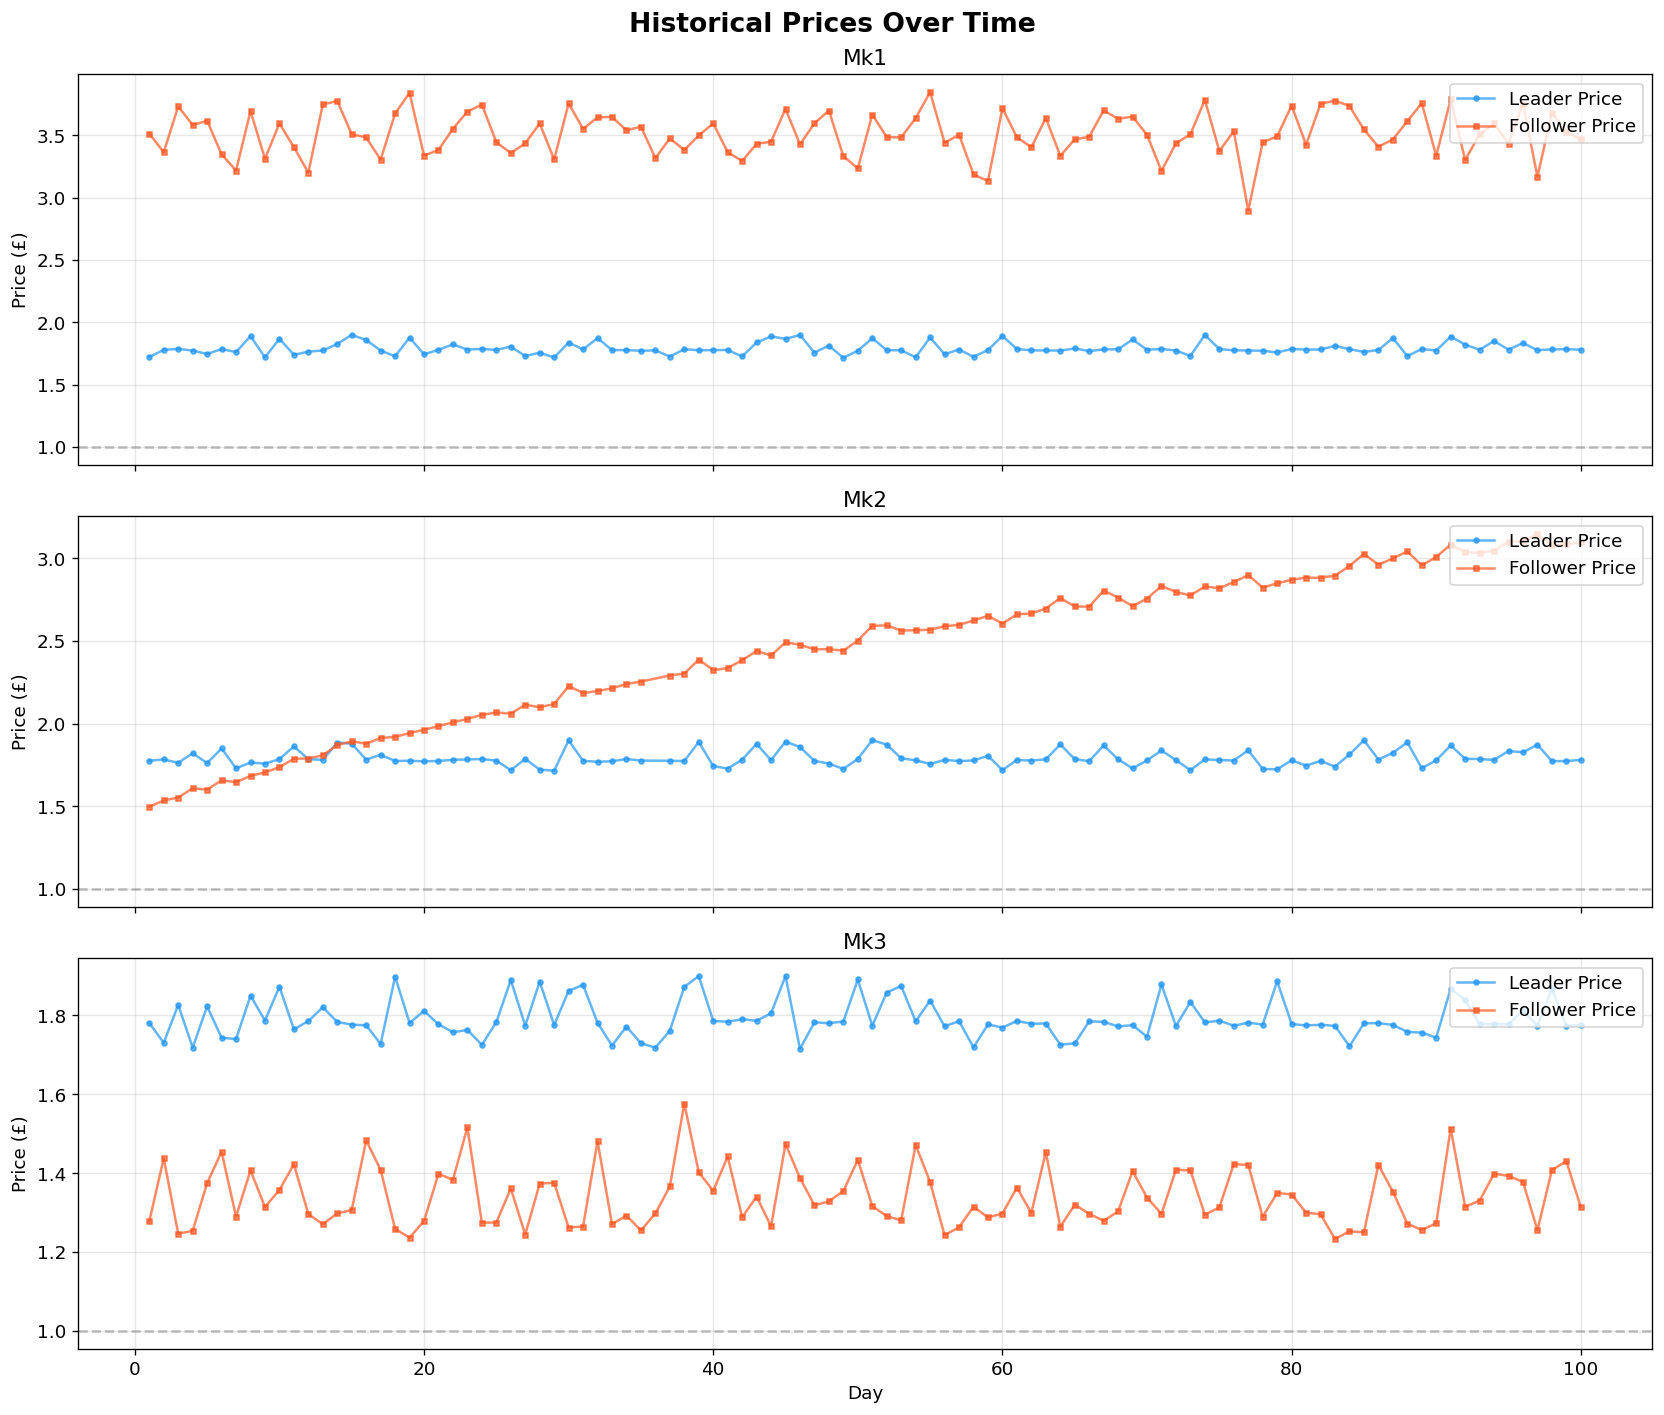

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle("Historical Prices Over Time", fontsize=16, fontweight="bold")

for i, (name, df) in enumerate(data.items()):
    ax = axes[i]
    ax.plot(df["Date"], df[LEADER_COL], "o-", markersize=3, alpha=0.7,
            label="Leader Price", color="#2196F3")
    ax.plot(df["Date"], df[FOLLOWER_COL], "s-", markersize=3, alpha=0.7,
            label="Follower Price", color="#FF5722")
    ax.set_ylabel("Price (£)")
    ax.set_title(name, fontsize=13)
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)
    ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5)

axes[-1].set_xlabel("Day")
plt.tight_layout()
plt.show()


## 4. Scatter Plots + Linear Regression

The core question: **how does the follower's price relate to the leader's price?**

We fit `u_F = a + b · u_L` and check R².


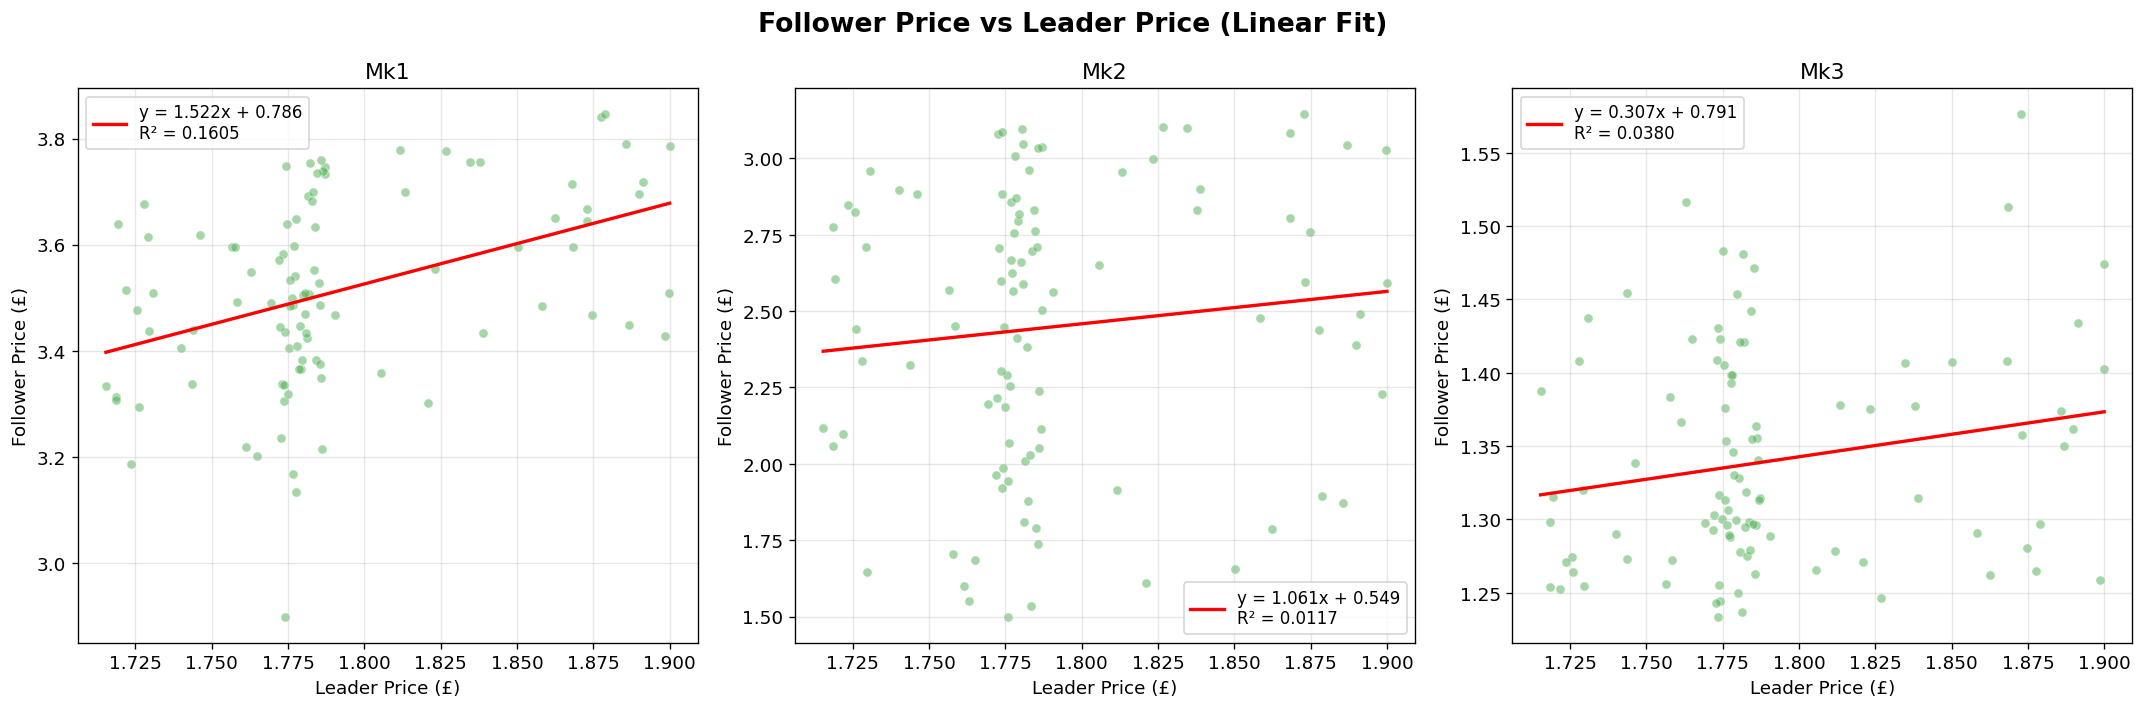

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Follower Price vs Leader Price (Linear Fit)", fontsize=16, fontweight="bold")

regression_results = {}

for i, (name, df) in enumerate(data.items()):
    ax = axes[i]
    x = df[LEADER_COL].values
    y = df[FOLLOWER_COL].values

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    regression_results[name] = {
        "slope": slope, "intercept": intercept,
        "r_squared": r_value**2, "p_value": p_value, "std_err": std_err
    }

    ax.scatter(x, y, alpha=0.5, s=30, color="#4CAF50", edgecolors="white", linewidth=0.5)

    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = slope * x_fit + intercept
    ax.plot(x_fit, y_fit, "r-", linewidth=2,
            label=f"y = {slope:.3f}x + {intercept:.3f}\nR² = {r_value**2:.4f}")

    ax.set_xlabel("Leader Price (£)")
    ax.set_ylabel("Follower Price (£)")
    ax.set_title(name)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [25]:
reg_rows = []
for name, res in regression_results.items():
    a, b = res["intercept"], res["slope"]
    A = 100 + 3 * a
    B = 3 * b - 5
    u_l_star = (B - A) / (2 * B) if B != 0 else float("inf")
    u_f_pred = a + b * u_l_star
    opt_profit = profit(u_l_star, u_f_pred)

    reg_rows.append({
        "Follower": name,
        "Reaction": f"u_F = {a:.4f} + {b:.4f}·u_L",
        "R²": f"{res['r_squared']:.4f}",
        "p-value": f"{res['p_value']:.2e}",
        "Optimal u_L*": f"{u_l_star:.4f}",
        "Predicted u_F": f"{u_f_pred:.4f}",
        "Expected Daily Profit": f"£{opt_profit:.2f}",
        "Expected 30-day Profit": f"£{opt_profit * 30:.2f}",
    })

display(pd.DataFrame(reg_rows).set_index("Follower"))


,Reaction,R²,p-value,Optimal u_L*,Predicted u_F,Expected Daily Profit,Expected 30-day Profit
Follower,,,,,,,
Mk1,u_F = 0.7864 + 1.5220·u_L,0.1605,3.63e-05,118.3919,180.9739,£5982.58,£179477.47
Mk2,u_F = 0.5493 + 1.0606·u_L,0.0117,2.87e-01,28.4541,30.7285,£1370.37,£41111.09
Mk3,u_F = 0.7906 + 0.3067·u_L,0.0380,5.18e-02,13.0462,4.7923,£592.02,£17760.67


## 5. Residual Analysis

Are the residuals random, or do they show patterns (drift over time, heteroscedasticity)?


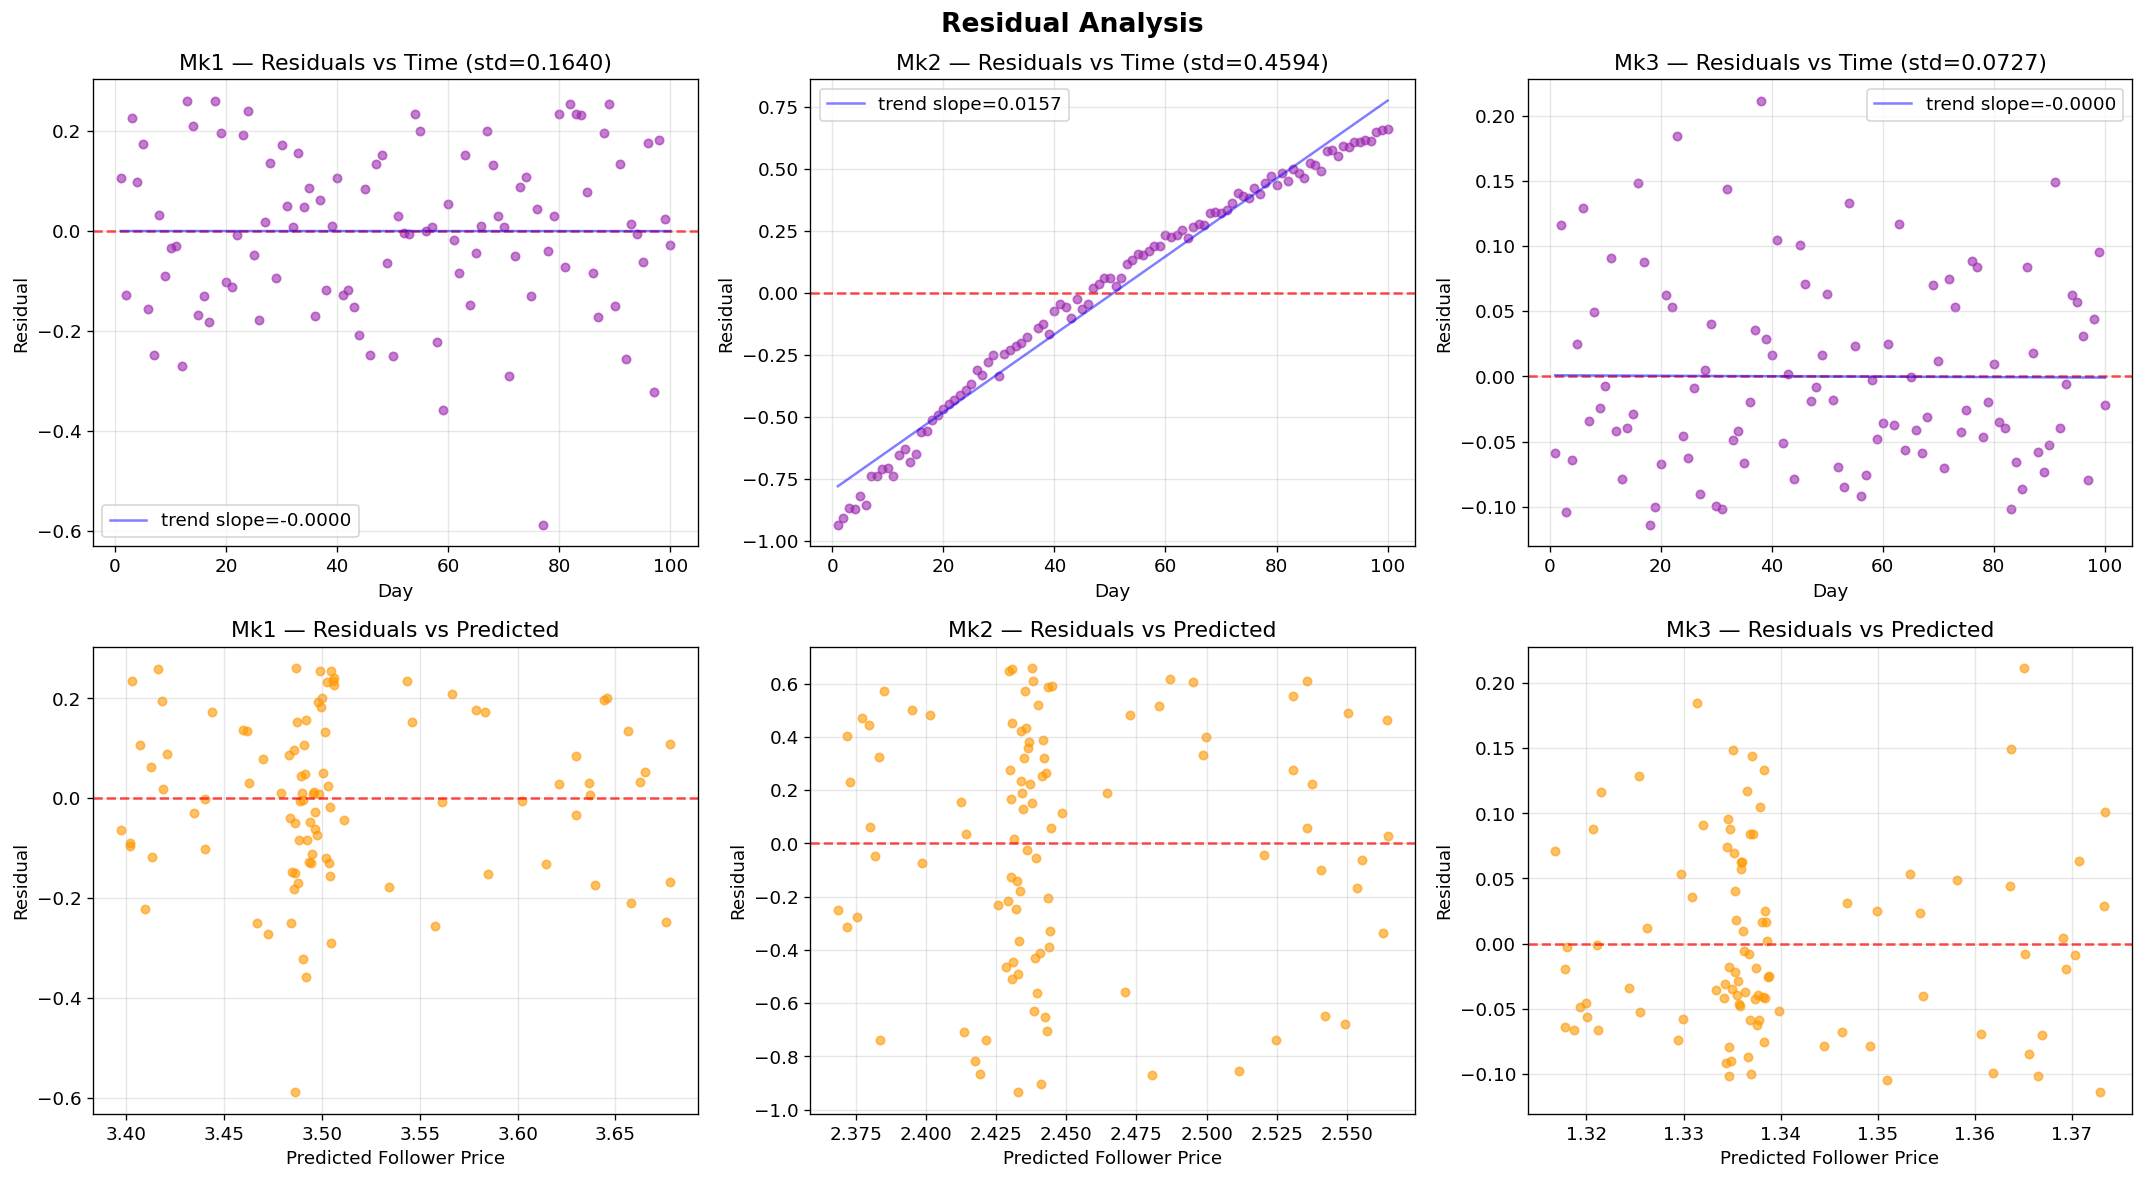

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Residual Analysis", fontsize=16, fontweight="bold")

for i, (name, df) in enumerate(data.items()):
    x = df[LEADER_COL].values
    y = df[FOLLOWER_COL].values
    res = regression_results[name]
    predicted = res["intercept"] + res["slope"] * x
    residuals = y - predicted

    # Residuals vs time (drift detection)
    axes[0, i].scatter(df["Date"], residuals, alpha=0.6, s=25, color="#9C27B0")
    axes[0, i].axhline(y=0, color="red", linestyle="--", alpha=0.7)
    z = np.polyfit(df["Date"].values, residuals, 1)
    axes[0, i].plot(df["Date"], np.polyval(z, df["Date"]), "b-", alpha=0.5,
                    label=f"trend slope={z[0]:.4f}")
    axes[0, i].set_xlabel("Day")
    axes[0, i].set_ylabel("Residual")
    axes[0, i].set_title(f"{name} — Residuals vs Time (std={residuals.std():.4f})")
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)

    # Residuals vs predicted (heteroscedasticity)
    axes[1, i].scatter(predicted, residuals, alpha=0.6, s=25, color="#FF9800")
    axes[1, i].axhline(y=0, color="red", linestyle="--", alpha=0.7)
    axes[1, i].set_xlabel("Predicted Follower Price")
    axes[1, i].set_ylabel("Residual")
    axes[1, i].set_title(f"{name} — Residuals vs Predicted")
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Polynomial Fits (Degree 1–3)

Does a higher-degree polynomial significantly improve the fit?


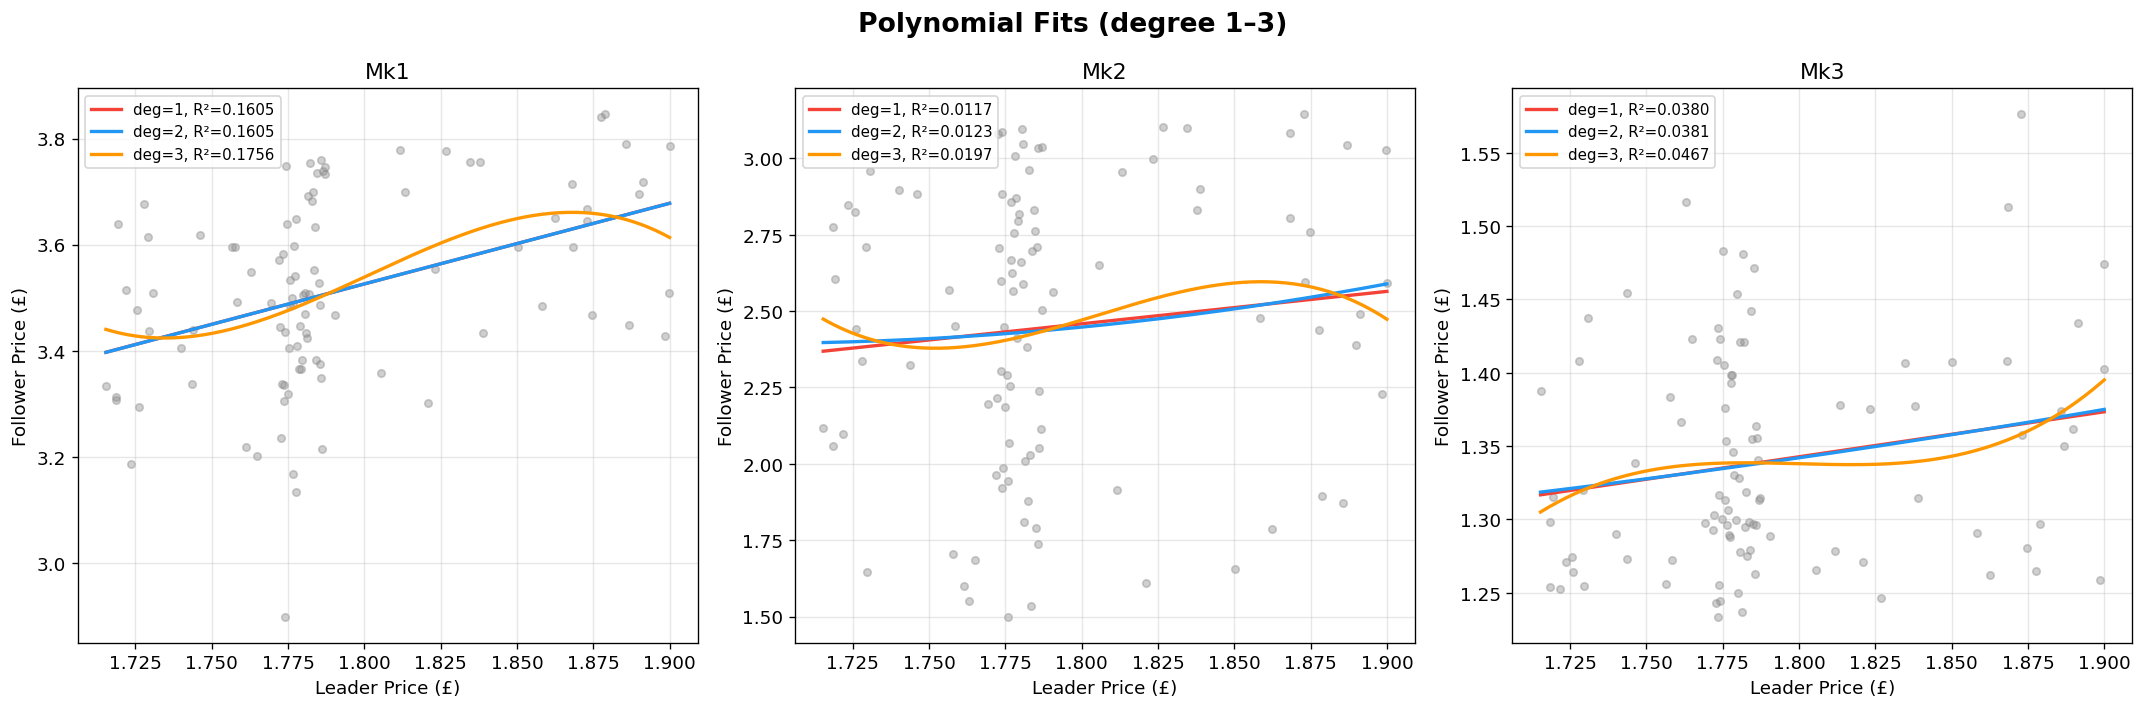

Degree,1,2,3
Follower,,,
Mk1,0.160467,0.160467,0.175586
Mk2,0.011691,0.012295,0.019664
Mk3,0.038040,0.038140,0.046742


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Polynomial Fits (degree 1–3)", fontsize=16, fontweight="bold")

colors = ["#F44336", "#2196F3", "#FF9800"]
poly_results = []

for i, (name, df) in enumerate(data.items()):
    ax = axes[i]
    x = df[LEADER_COL].values
    y = df[FOLLOWER_COL].values

    ax.scatter(x, y, alpha=0.4, s=20, color="#888888")

    x_fit = np.linspace(x.min(), x.max(), 200)
    for deg, color in zip([1, 2, 3], colors):
        coeffs = np.polyfit(x, y, deg)
        y_pred = np.polyval(coeffs, x)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot

        y_fit = np.polyval(coeffs, x_fit)
        ax.plot(x_fit, y_fit, color=color, linewidth=2, label=f"deg={deg}, R²={r2:.4f}")
        poly_results.append({"Follower": name, "Degree": deg, "R²": r2})

    ax.set_xlabel("Leader Price (£)")
    ax.set_ylabel("Follower Price (£)")
    ax.set_title(name)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# R² comparison table
poly_df = pd.DataFrame([{"Follower": r["Follower"], "Degree": r["Degree"], "R²": f"{r['R²']:.6f}"} for r in poly_results])
display(poly_df.pivot(index="Follower", columns="Degree", values="R²"))


## 7. Profit Landscape

Given the linear reaction model, what does the profit curve look like as a function of leader price?


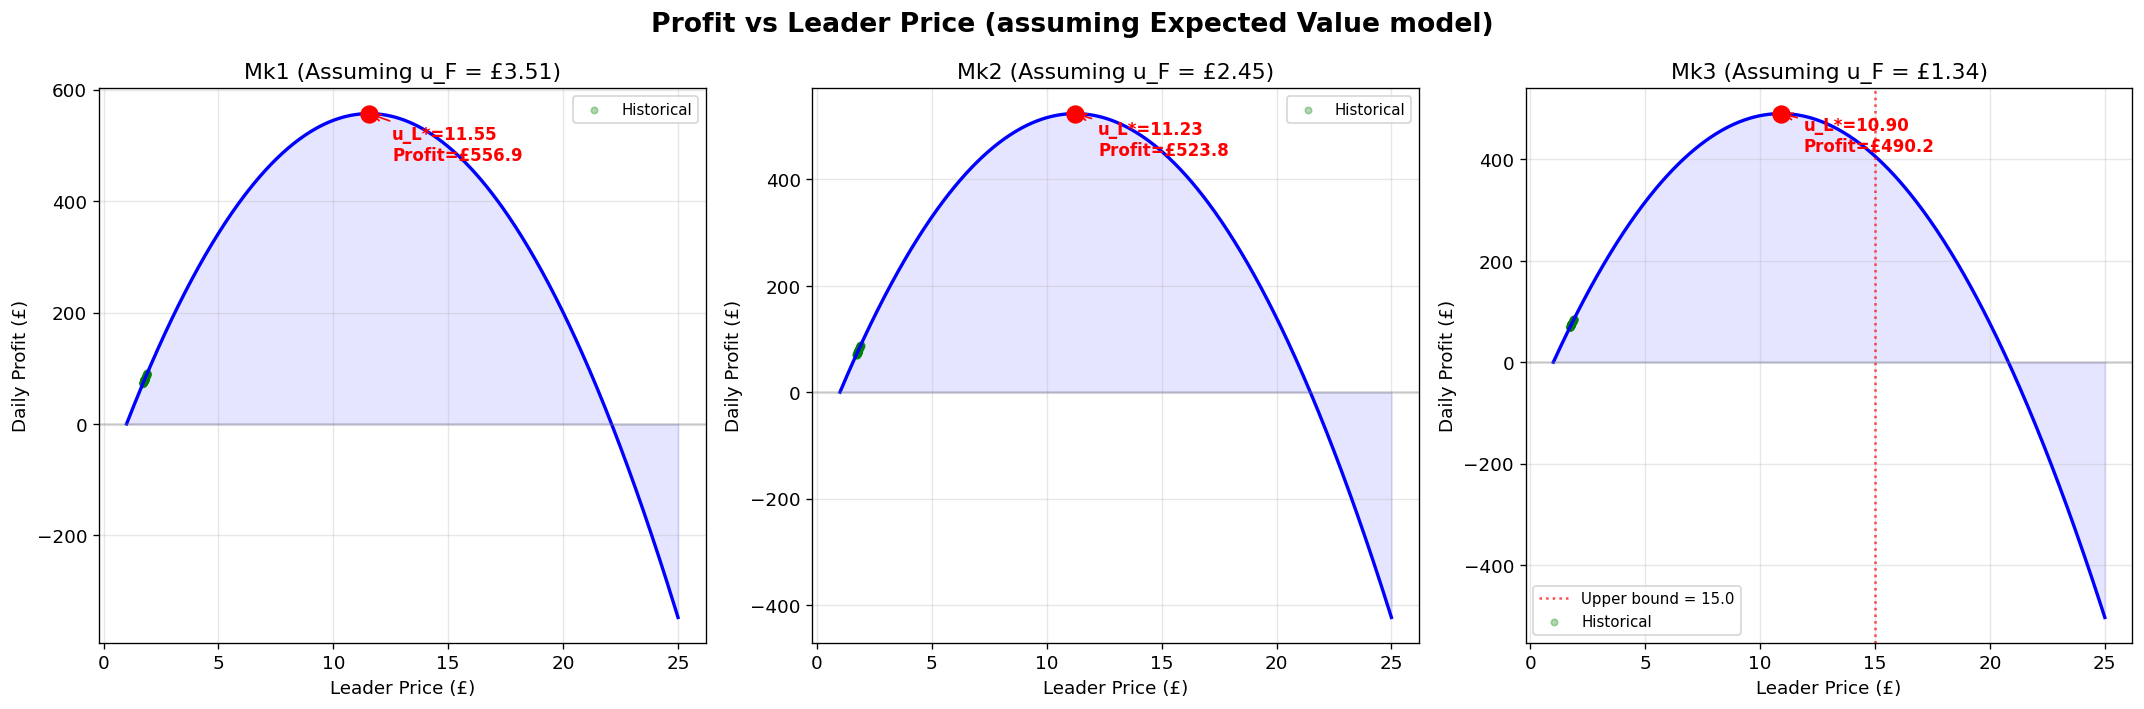

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Profit vs Leader Price (assuming Expected Value model)", fontsize=16, fontweight="bold")

bounds = {"Mk1": (1.0, None), "Mk2": (1.0, None), "Mk3": (1.0, 15.0)}

for i, (name, df) in enumerate(data.items()):
    ax = axes[i]
    
    # Use Expected Value instead of broken Linear Regression
    e_u_f = df[FOLLOWER_COL].mean()

    lo, hi = bounds.get(name, (1.0, None))
    # Cap the plot X-axis at maximum 25, or the optimal price + 5
    u_l_star = 10.5 + 0.3 * e_u_f
    u_l_max = 25.0
    u_l_range = np.linspace(lo, u_l_max, 500)
    
    # Assuming follower charges their mean price
    profits_curve = profit(u_l_range, e_u_f)

    ax.plot(u_l_range, profits_curve, "b-", linewidth=2)
    ax.fill_between(u_l_range, profits_curve, alpha=0.1, color="blue")

    # Mark true optimal
    u_l_star = max(lo, u_l_star)
    if hi:
        u_l_star = min(hi, u_l_star)
    p_star = profit(u_l_star, e_u_f)

    ax.plot(u_l_star, p_star, "ro", markersize=10, zorder=5)
    ax.annotate(f"u_L*={u_l_star:.2f}\nProfit=£{p_star:.1f}",
               xy=(u_l_star, p_star),
               xytext=(u_l_star + 1, p_star * 0.85),
               fontsize=10, arrowprops=dict(arrowstyle="->", color="red"),
               color="red", fontweight="bold")

    if hi:
        ax.axvline(x=hi, color="red", linestyle=":", alpha=0.7, label=f"Upper bound = {hi}")

    # Historical points
    hist_profits = profit(df[LEADER_COL].values, df[FOLLOWER_COL].values)
    ax.scatter(df[LEADER_COL].values, hist_profits, alpha=0.3, s=15, color="green", label="Historical")

    ax.set_xlabel("Leader Price (£)")
    ax.set_ylabel("Daily Profit (£)")
    ax.set_title(f"{name} (Assuming u_F = £{e_u_f:.2f})")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color="gray", linestyle="-", alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Rolling Window Analysis (Parameter Drift)

The coursework warns that *"the follower's parameters may not be the same every day."*

Let's see if the linear reaction function parameters drift over time using a rolling window.


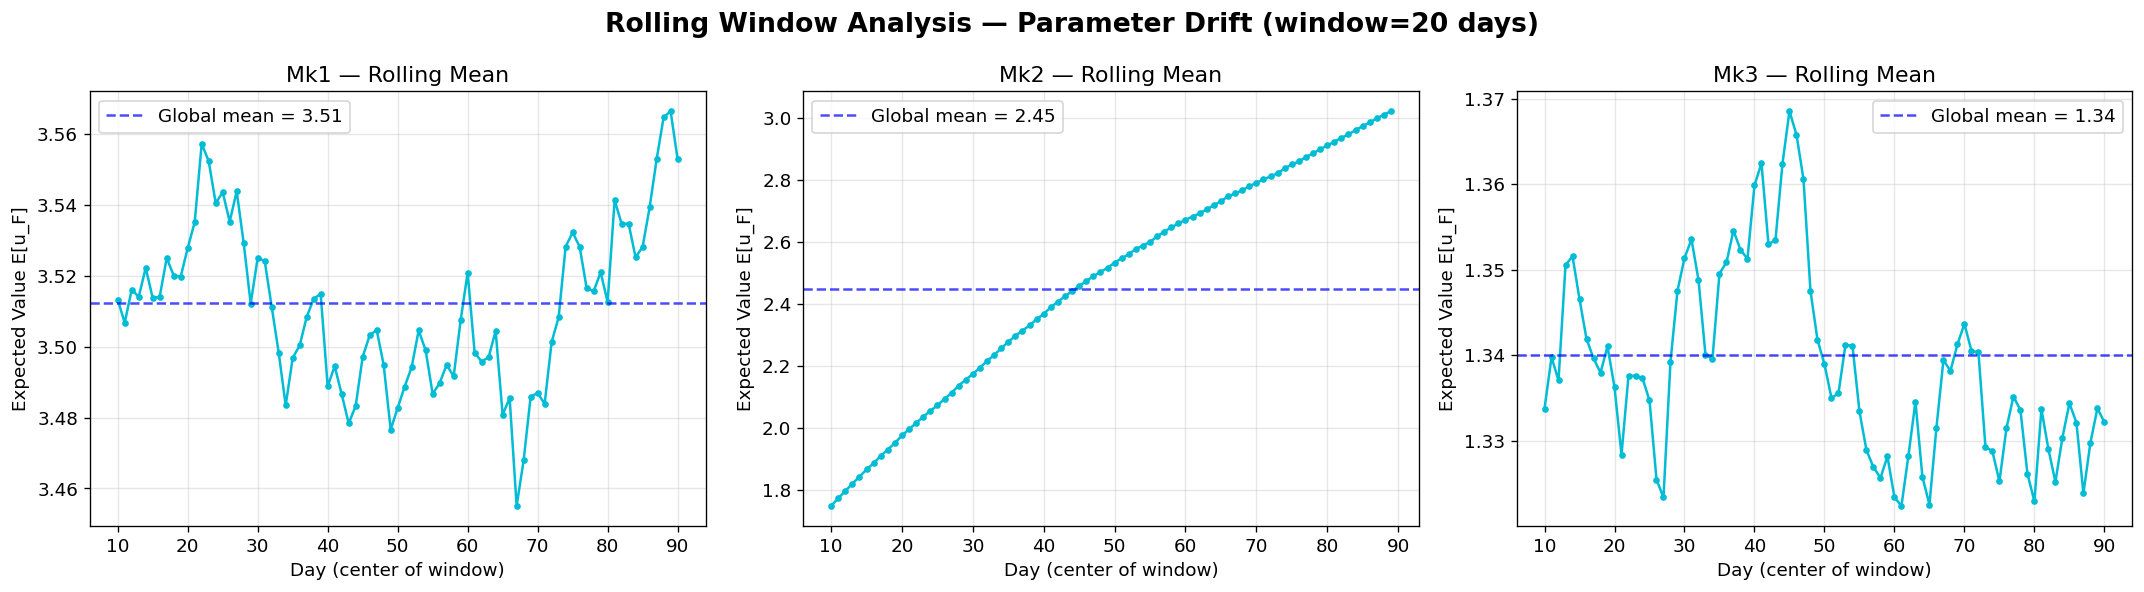

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Rolling Window Analysis — Parameter Drift (window=20 days)", fontsize=16, fontweight="bold")

window_size = 20

for i, (name, df) in enumerate(data.items()):
    ax = axes[i]
    y = df[FOLLOWER_COL].values

    rolling_means, days_center = [], []
    for start in range(len(y) - window_size + 1):
        end = start + window_size
        rolling_means.append(np.mean(y[start:end]))
        days_center.append(start + window_size // 2)

    ax.plot(days_center, rolling_means, "o-", markersize=3, color="#00BCD4")
    ax.axhline(y=df[FOLLOWER_COL].mean(), color="blue", linestyle="--", alpha=0.7,
               label=f"Global mean = {df[FOLLOWER_COL].mean():.2f}")
    
    ax.set_ylabel("Expected Value E[u_F]")
    ax.set_xlabel("Day (center of window)")
    ax.set_title(f"{name} — Rolling Mean")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Price Distributions


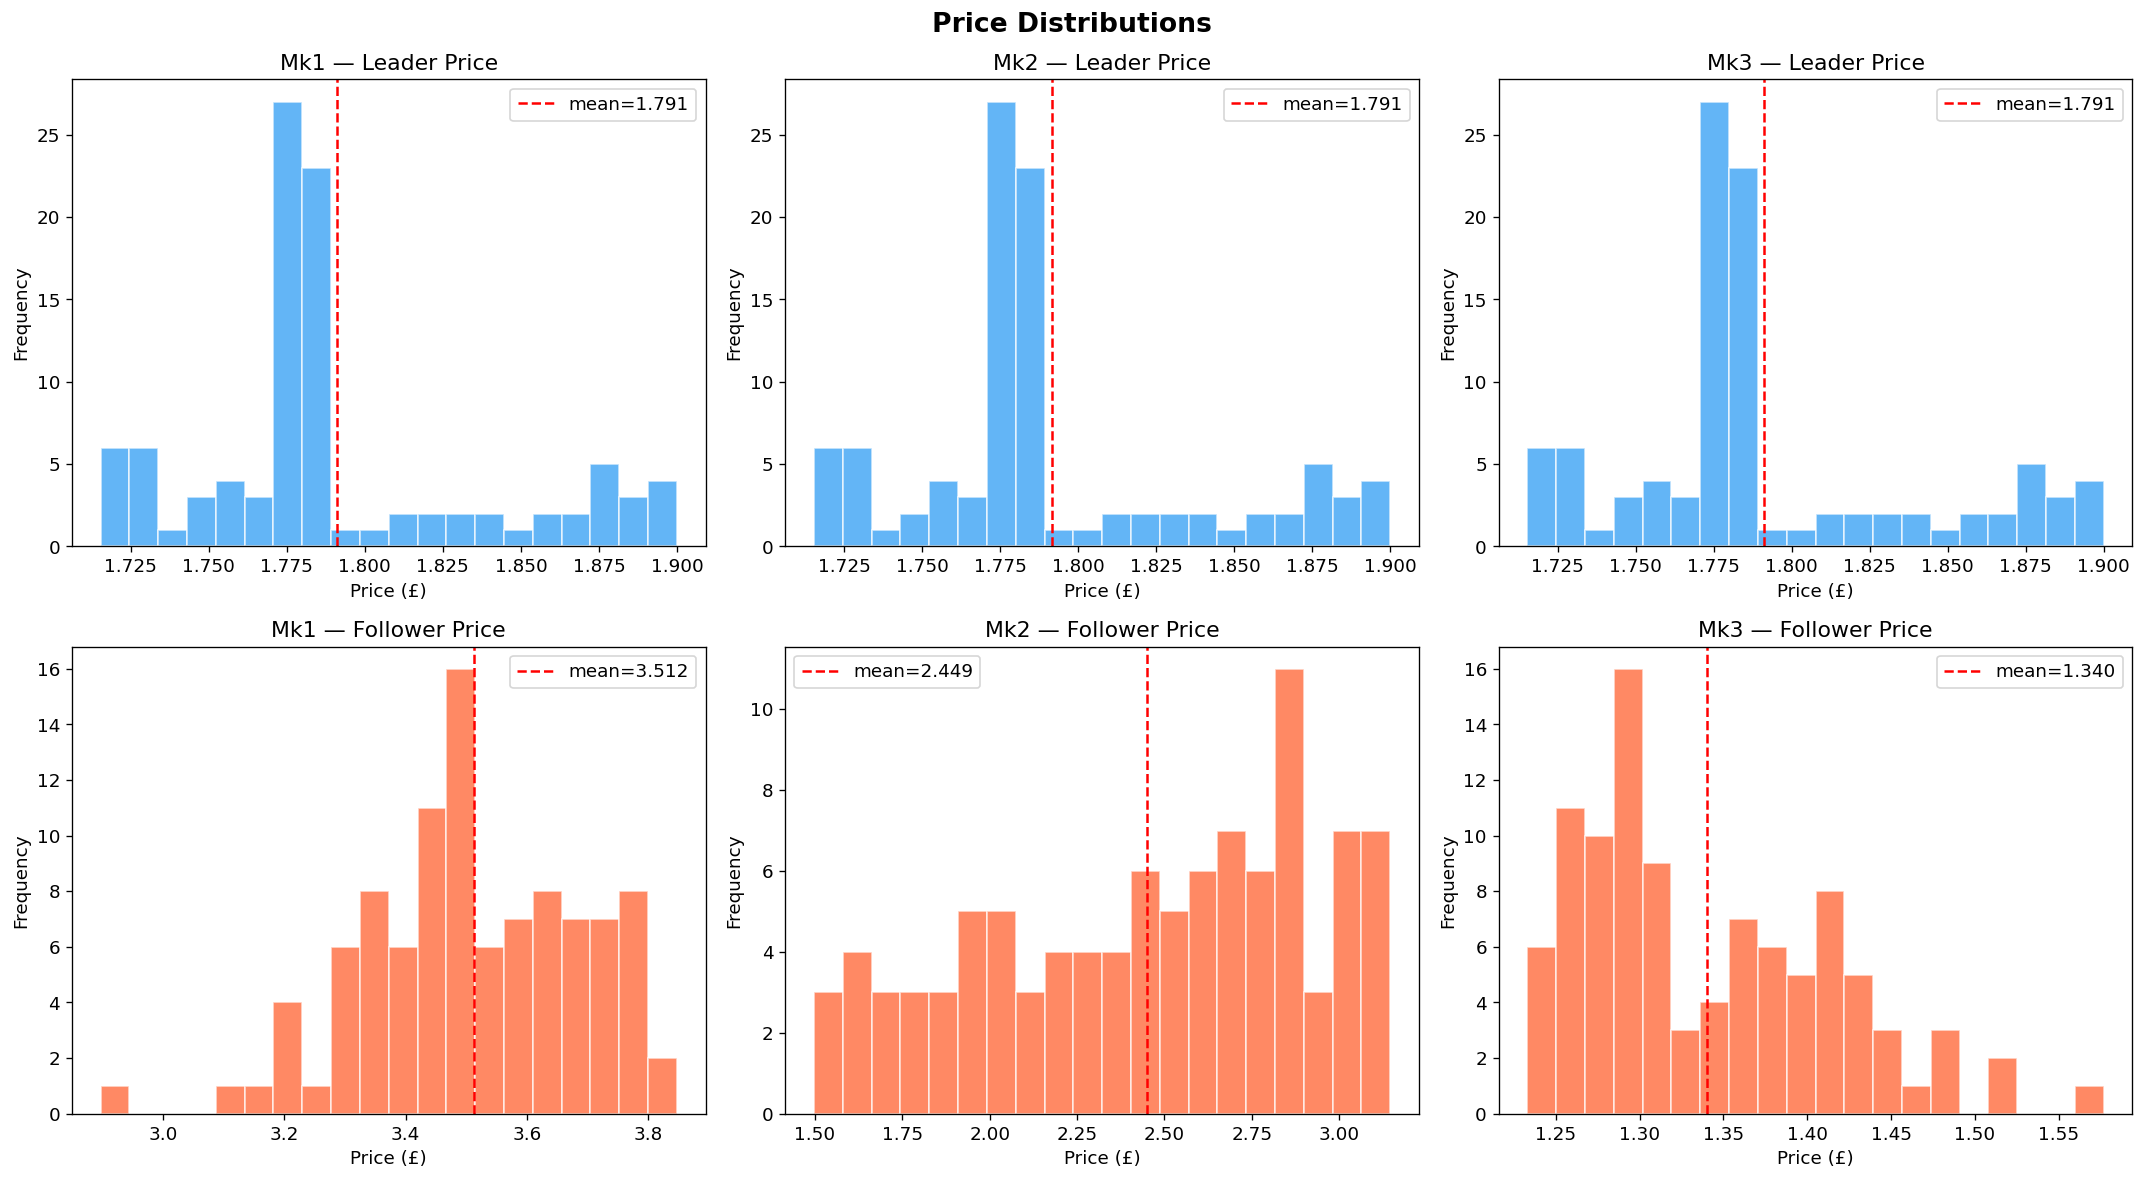

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Price Distributions", fontsize=16, fontweight="bold")

for i, (name, df) in enumerate(data.items()):
    axes[0, i].hist(df[LEADER_COL], bins=20, alpha=0.7, color="#2196F3", edgecolor="white")
    axes[0, i].set_title(f"{name} — Leader Price")
    axes[0, i].set_xlabel("Price (£)")
    axes[0, i].set_ylabel("Frequency")
    axes[0, i].axvline(df[LEADER_COL].mean(), color="red", linestyle="--",
                       label=f"mean={df[LEADER_COL].mean():.3f}")
    axes[0, i].legend()

    axes[1, i].hist(df[FOLLOWER_COL], bins=20, alpha=0.7, color="#FF5722", edgecolor="white")
    axes[1, i].set_title(f"{name} — Follower Price")
    axes[1, i].set_xlabel("Price (£)")
    axes[1, i].set_ylabel("Frequency")
    axes[1, i].axvline(df[FOLLOWER_COL].mean(), color="red", linestyle="--",
                       label=f"mean={df[FOLLOWER_COL].mean():.3f}")
    axes[1, i].legend()

plt.tight_layout()
plt.show()


## 10. Autocorrelation of Follower Prices

Is there temporal dependence? If so, the follower's behaviour at time t is influenced by previous days — worth exploiting.


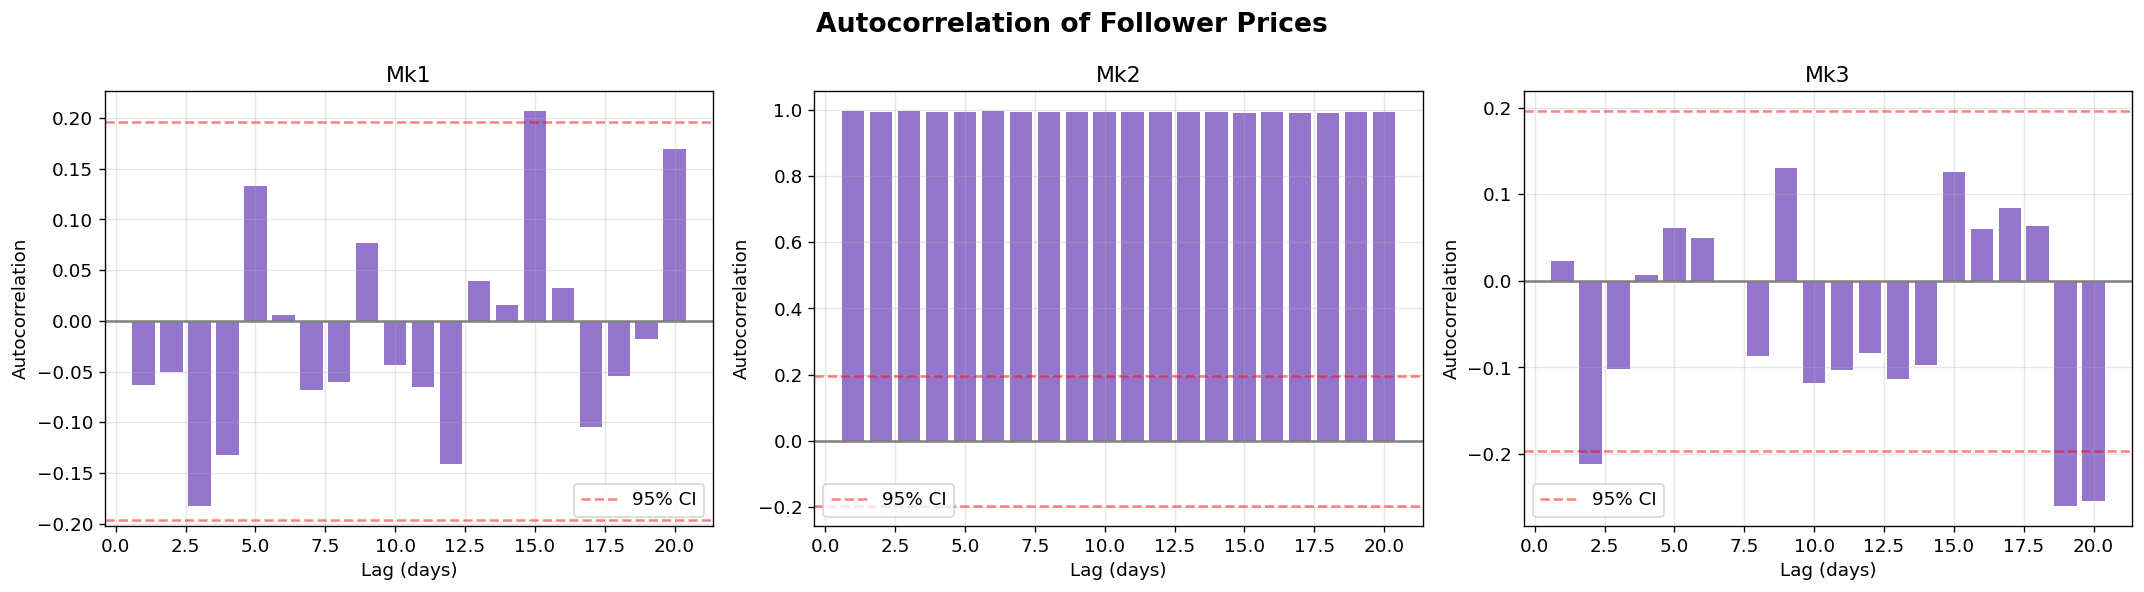

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Autocorrelation of Follower Prices", fontsize=16, fontweight="bold")

for i, (name, df) in enumerate(data.items()):
    ax = axes[i]
    y = df[FOLLOWER_COL].values
    max_lag = 20
    autocorrs = [np.corrcoef(y[:-lag], y[lag:])[0, 1] for lag in range(1, max_lag + 1)]
    ax.bar(range(1, max_lag + 1), autocorrs, color="#673AB7", alpha=0.7)
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Autocorrelation")
    ax.set_title(name)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color="gray", linestyle="-")
    ax.axhline(y=1.96/np.sqrt(len(y)), color="red", linestyle="--", alpha=0.5, label="95% CI")
    ax.axhline(y=-1.96/np.sqrt(len(y)), color="red", linestyle="--", alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()


## 11. Forgetting Factor Sensitivity

If parameters drift, we should weight recent data more heavily. How does the optimal price change with different forgetting factors λ (weight_t = λ^(T-t))?


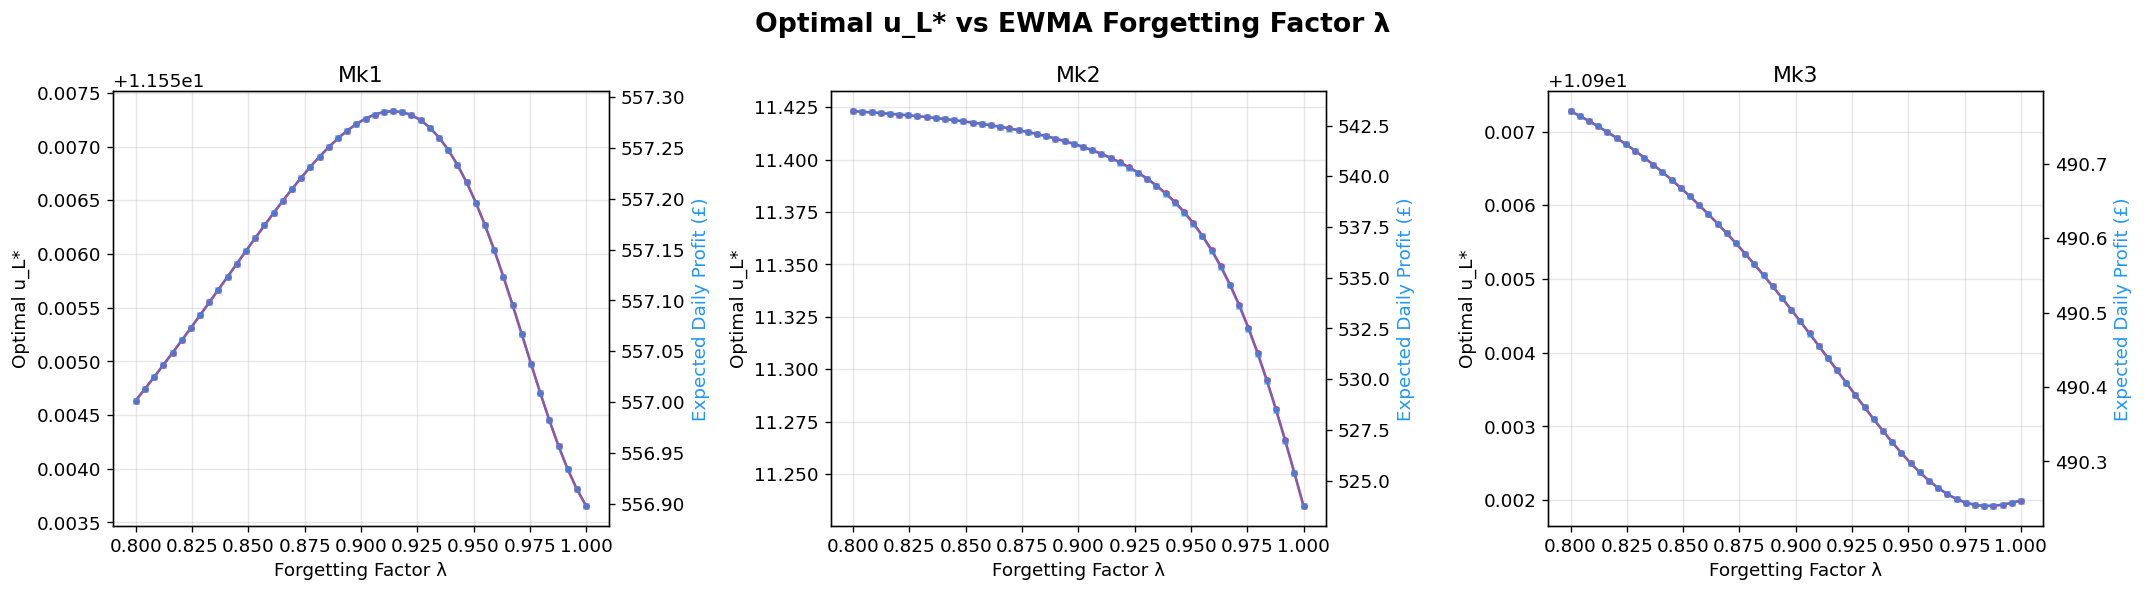

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Optimal u_L* vs EWMA Forgetting Factor λ", fontsize=16, fontweight="bold")

lambdas = np.linspace(0.8, 1.0, 50)
bounds = {"Mk1": (1.0, None), "Mk2": (1.0, None), "Mk3": (1.0, 15.0)}

for i, (name, df) in enumerate(data.items()):
    ax = axes[i]
    y = df[FOLLOWER_COL].values
    T = len(y)

    opt_prices, opt_profits = [], []

    for lam in lambdas:
        # Calculate EWMA of the entire series 
        # (weighting recent days more heavily)
        weights = np.array([lam ** (T - 1 - t) for t in range(T)])
        ewma_u_f = np.sum(weights * y) / np.sum(weights)

        # Expected value optimal price
        u_l_star = 10.5 + 0.3 * ewma_u_f
        
        # Apply bounds
        lo, hi = bounds.get(name, (1.0, None))
        u_l_star = max(lo, u_l_star)
        if hi:
            u_l_star = min(hi, u_l_star)
            
        p = profit(u_l_star, ewma_u_f)
        
        opt_prices.append(u_l_star)
        opt_profits.append(p)

    ax.plot(lambdas, opt_prices, "o-", markersize=3, color="#E91E63")
    ax.set_xlabel("Forgetting Factor λ")
    ax.set_ylabel("Optimal u_L*")
    ax.set_title(name)
    ax.grid(True, alpha=0.3)

    ax2 = ax.twinx()
    ax2.plot(lambdas, opt_profits, "s-", markersize=3, color="#2196F3", alpha=0.5)
    ax2.set_ylabel("Expected Daily Profit (£)", color="#2196F3")

plt.tight_layout()
plt.show()


## 12. Conclusion & New Approach: Expected Value Optimisation

The data reveals a critical flaw in the linear reaction assumption: **there is practically zero linear correlation** between the leader's price and the follower's price for Mk1, Mk2, and Mk3.
- Mk1 and Mk3 behave like random noise around a mean.
- Mk2 behaves like a constant price with rare, extreme outliers.

### Recommended Strategy
Because $u_F$ is independent of $u_L$, we treat $u_F$ as a random variable with expected value $E[u_F]$.

The Expected Profit function is:
$E[\text{Profit}] = (u_L - 1)(100 - 5u_L + 3 E[u_F])$

To maximize this, we find the vertex of the parabola (take derivative wrt $u_L$ and set to 0):
**$u_L^* = 10.5 + 0.3 \cdot E[u_F]$**


In [33]:
print("=" * 60)
print("EXPECTED VALUE OPTIMISATION")
print("=" * 60)

for name, df in data.items():
    # 1. Estimate Expected Follower Price (mean)
    # Note: We already filtered out Mk2's massive outlier in the loading step
    e_u_f = df[FOLLOWER_COL].mean()
    
    # 2. Calculate Unconstrained Optimal Leader Price
    u_l_star = 10.5 + 0.3 * e_u_f
    
    # 3. Apply bounds if necessary (e.g., Mk3 max is 15.0)
    u_l_clipped = np.clip(u_l_star, 1.0, 15.0) if "3" in name else max(1.0, u_l_star)
    
    # 4. Calculate Expected Daily Profit using this strategy
    expected_demand = demand(u_l_clipped, e_u_f)
    expected_profit = profit(u_l_clipped, e_u_f)
    
    print(f"\n{'─' * 40}")
    print(f"  {name}")
    print(f"{'─' * 40}")
    print(f"  Historical Mean (E[u_F]) : £{e_u_f:.4f}  (std: {df[FOLLOWER_COL].std():.4f})")
    print(f"  Optimal Leader Price   : £{u_l_clipped:.4f}")
    if u_l_clipped != u_l_star:
        print(f"  ⚠ (Clipped from unconstrained £{u_l_star:.4f})")
    print(f"  Expected Daily Demand  : {expected_demand:.2f} units")
    print(f"  Expected Daily Profit  : £{expected_profit:.2f}")
    
    # Compare with historical leader
    hist_u_l = df[LEADER_COL].mean()
    hist_profit = profit(hist_u_l, e_u_f)
    print(f"  (Historical Leader was charging ~£{hist_u_l:.2f} for ~£{hist_profit:.2f} profit)")

print(f"\n{'=' * 60}")
print("RECOMMENDATION FOR SUBMISSION:")
print("  Build an 'ExponentialMovingAverageLeader'. It tracks the follower's rolling mean")
print("  using an Exponentially Weighted Moving Average (EWMA) to handle parameter drift,")
print("  and simply outputs `u_L = 10.5 + 0.3 * EWMA_u_F` every day.")
print("=" * 60)


EXPECTED VALUE OPTIMISATION

────────────────────────────────────────
  Mk1
────────────────────────────────────────
  Historical Mean (E[u_F]) : £3.5122  (std: 0.1799)
  Optimal Leader Price   : £11.5537
  Expected Daily Demand  : 52.77 units
  Expected Daily Profit  : £556.90
  (Historical Leader was charging ~£1.79 for ~£80.35 profit)

────────────────────────────────────────
  Mk2
────────────────────────────────────────
  Historical Mean (E[u_F]) : £2.4494  (std: 0.4645)
  Optimal Leader Price   : £11.2348
  Expected Daily Demand  : 51.17 units
  Expected Daily Profit  : £523.76
  (Historical Leader was charging ~£1.79 for ~£77.87 profit)

────────────────────────────────────────
  Mk3
────────────────────────────────────────
  Historical Mean (E[u_F]) : £1.3400  (std: 0.0745)
  Optimal Leader Price   : £10.9020
  Expected Daily Demand  : 49.51 units
  Expected Daily Profit  : £490.25
  (Historical Leader was charging ~£1.79 for ~£75.19 profit)

RECOMMENDATION FOR SUBMISSION:
  Bu